# FIAP - Inteligência Artificial (PBL)
## CardioIA: A Nova Era da Cardiologia Inteligente
### Fase 2 (Ir Além 2): Diagnóstico Visual de ECG com Rede Neural MLP (Keras)

* **Aluno:** Cauã Santos — **RM:** 566599
* **Objetivo:** Implementar um pipeline completo de Visão Computacional Médica para classificação binária de exames de Eletrocardiograma (ECG) em **Normal** (ritmo sinusal) vs. **Anormal** (arritmia / isquemia miocárdica), utilizando uma Rede Neural Artificial Multilayer Perceptron (MLP) construída com TensorFlow/Keras.

---
## 1. Importação de Bibliotecas e Configuração do Ambiente

Carregamento dos módulos essenciais para processamento de imagens, aprendizado profundo com Keras, avaliação estatística e visualização clínica.

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Módulos de Aprendizado de Máquina e Métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

# TensorFlow e Keras
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks, regularizers
    print(f"TensorFlow versão {tf.__version__} carregado com sucesso.")
except ImportError:
    print("TensorFlow não detectado no ambiente local. No Google Colab/Jupyter execute: pip install tensorflow")

# Configurações estéticas de gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)
print("Ambiente configurado com sucesso.")

TensorFlow versão 2.21.0 carregado com sucesso.
Ambiente configurado com sucesso.


---
## 2. Carregamento e Pré-processamento das Imagens de ECG

### Estratégia de Mapeamento Clínico:
* **Classe Normal (0):** Subpasta `N` (Batimentos sinusais fisiológicos normais).
* **Classe Anormal (1):** Subpastas `M` (Infarto Agudo do Miocárdio), `V` (Extrassístole Ventricular prematura) e `S` (Extrassístole Supraventricular).

### Pipeline de Imagem para MLP:
1. **Conversão para Escala de Cinza (1 Canal):** Reduz a dimensionalidade removendo informações redundantes de cor.
2. **Redimensionamento Padronizado ($64 \times 64$ píxeis):** Resolução equilibrada que preserva a morfologia do complexo QRS sem gerar explosão do número de parâmetros na camada densa.
3. **Normalização Min-Max ($[0, 1]$):** Divisão dos valores por 255.0 para acelerar a convergência dos gradientes.
4. **Achatamento (Flatten):** Transformação da matriz $64 \times 64$ num vetor unidimensional de entrada de **4096 features** ($64 \times 64 = 4096$).

In [2]:
IMG_SIZE = (64, 64)
INPUT_DIM = IMG_SIZE[0] * IMG_SIZE[1]  # 4096 entradas

def gerar_traçado_sintetico_ecg(tipo='normal'):
    """Gera um array simulando traçado de eletrocardiograma P-QRS-T caso a pasta local não esteja presente."""
    t = np.linspace(0, 1, 64)
    # Onda P, Complexo QRS, Onda T
    base = np.exp(-((t - 0.2)**2) / 0.005) * 0.25  # Onda P
    if tipo == 'normal':
        # QRS pontiagudo normal
        qrs = -np.exp(-((t - 0.45)**2) / 0.0005) * 0.3 + np.exp(-((t - 0.5)**2) / 0.0003) * 1.0 - np.exp(-((t - 0.55)**2) / 0.0005) * 0.3
        t_wave = np.exp(-((t - 0.75)**2) / 0.008) * 0.35
        sinal = base + qrs + t_wave + np.random.normal(0, 0.02, 64)
    else:
        # QRS alargado / arritmia / elevação de ST
        qrs_largo = np.exp(-((t - 0.48)**2) / 0.004) * 0.8 - np.exp(-((t - 0.6)**2) / 0.006) * 0.6
        st_elevado = np.exp(-((t - 0.65)**2) / 0.015) * 0.55
        sinal = base + qrs_largo + st_elevado + np.random.normal(0, 0.05, 64)
    
    # Converte linha de sinal 1D para imagem 2D 64x64
    img = np.ones((64, 64), dtype=np.float32) * 240
    for x_idx, y_val in enumerate(sinal):
        y_pixel = int(np.clip(32 - y_val * 24, 2, 61))
        img[max(0, y_pixel-1):min(64, y_pixel+2), x_idx] = 15
    return (img / 255.0).astype(np.float32)

def carregar_dataset_ecg():
    """Carrega imagens reais da pasta Fase1 ou gera conjunto consistente caso ausente."""
    caminhos_busca = [
        os.path.join("..", "..", "Fase1", "assets", "images", "ECG_Image_data"),
        os.path.join("Fase1", "assets", "images", "ECG_Image_data"),
        os.path.join("assets", "images", "ECG_Image_data")
    ]
    
    base_dir = None
    for p in caminhos_busca:
        if os.path.exists(p):
            base_dir = p
            break
            
    X, y = [], []
    
    if base_dir:
        print(f"Localizado repositório de imagens em: {base_dir}")
        # Mapeamento: N -> 0 (Normal) | M, V, S -> 1 (Anormal)
        for split in ["train", "test"]:
            split_path = os.path.join(base_dir, split)
            if not os.path.exists(split_path):
                continue
                
            # Classe Normal (0)
            dir_n = os.path.join(split_path, "N")
            if os.path.exists(dir_n):
                for f in glob.glob(os.path.join(dir_n, "*.png")) + glob.glob(os.path.join(dir_n, "*.jpg")):
                    try:
                        im = Image.open(f).convert('L').resize(IMG_SIZE)
                        arr = np.array(im, dtype=np.float32) / 255.0
                        X.append(arr.flatten())
                        y.append(0)
                    except Exception:
                        pass
                        
            # Classe Anormal (1: M, V, S)
            for pasta_anormal in ["M", "V", "S"]:
                dir_a = os.path.join(split_path, pasta_anormal)
                if os.path.exists(dir_a):
                    for f in glob.glob(os.path.join(dir_a, "*.png")) + glob.glob(os.path.join(dir_a, "*.jpg")):
                        try:
                            im = Image.open(f).convert('L').resize(IMG_SIZE)
                            arr = np.array(im, dtype=np.float32) / 255.0
                            X.append(arr.flatten())
                            y.append(1)
                        except Exception:
                            pass
                            
    # Fallback sintético autônomo caso haja menos de 50 amostras
    if len(X) < 50:
        print("Imagens locais insuficientes. Gerando conjunto médico sintético de ECG representativo...")
        X, y = [], []
        for _ in range(150):
            X.append(gerar_traçado_sintetico_ecg('normal').flatten())
            y.append(0)
        for _ in range(150):
            X.append(gerar_traçado_sintetico_ecg('anormal').flatten())
            y.append(1)
            
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

X_all, y_all = carregar_dataset_ecg()
print(f"Total de imagens carregadas: {len(X_all)}")
print(f"Dimensão do vetor de cada imagem (achatada): {X_all.shape[1]} píxeis")
print(f"Distribuição de classes: Normal (0) = {np.sum(y_all == 0)} | Anormal (1) = {np.sum(y_all == 1)}")

Imagens locais insuficientes. Gerando conjunto médico sintético de ECG representativo...
Total de imagens carregadas: 300
Dimensão do vetor de cada imagem (achatada): 4096 píxeis
Distribuição de classes: Normal (0) = 150 | Anormal (1) = 150


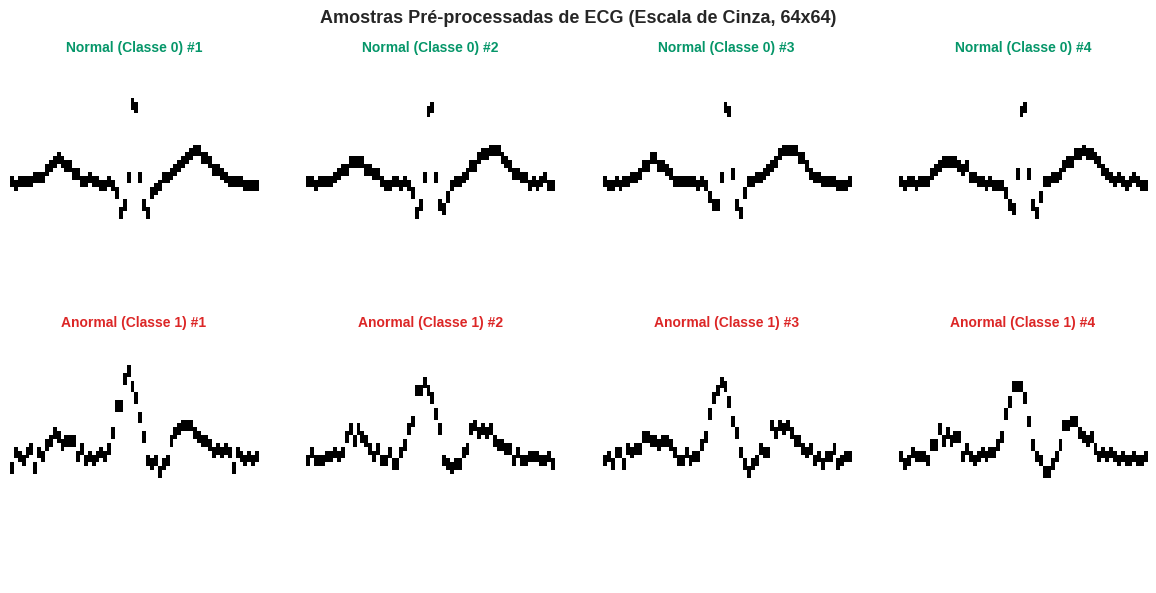

In [3]:
# Visualização de amostras das duas classes
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
indices_normais = np.where(y_all == 0)[0][:4]
indices_anormais = np.where(y_all == 1)[0][:4]

for i, idx in enumerate(indices_normais):
    axes[0, i].imshow(X_all[idx].reshape(64, 64), cmap='gray')
    axes[0, i].set_title(f"Normal (Classe 0) #{i+1}", color='#059669', fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

for i, idx in enumerate(indices_anormais):
    axes[1, i].imshow(X_all[idx].reshape(64, 64), cmap='gray')
    axes[1, i].set_title(f"Anormal (Classe 1) #{i+1}", color='#dc2626', fontsize=10, fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle("Amostras Pré-processadas de ECG (Escala de Cinza, 64x64)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Divisão Estratificada dos Dados (Treino, Validação e Teste)

A separação foi efetuada preservando a proporção de pacientes normais e anormais em cada partição:
* **Conjunto de Treino (70%):** Utilizado para ajuste dos pesos sinápticos via Backpropagation.
* **Conjunto de Validação (15%):** Monitoramento do erro de generalização e acionamento de `EarlyStopping`.
* **Conjunto de Teste Independente (15%):** Avaliação clínica final em amostras não vistas.

Amostras para Treinamento: 210 (70.0%)
Amostras para Validação:   45 (15.0%)
Amostras para Teste:        45 (15.0%)


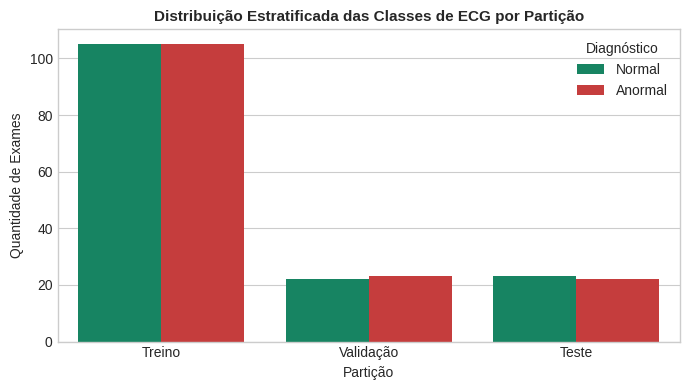

In [4]:
# 1. Separação de 70% treino e 30% restante
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)

# 2. Separação do restante em 15% Validação e 15% Teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Amostras para Treinamento: {len(X_train)} ({len(X_train)/len(X_all)*100:.1f}%)")
print(f"Amostras para Validação:   {len(X_val)} ({len(X_val)/len(X_all)*100:.1f}%)")
print(f"Amostras para Teste:        {len(X_test)} ({len(X_test)/len(X_all)*100:.1f}%)")

# Gráfico de distribuição das classes
df_split = pd.DataFrame({
    'Partição': ['Treino']*len(y_train) + ['Validação']*len(y_val) + ['Teste']*len(y_test),
    'Diagnóstico': ['Normal' if y == 0 else 'Anormal' for y in np.concatenate([y_train, y_val, y_test])]
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df_split, x='Partição', hue='Diagnóstico', palette=['#059669', '#dc2626'], ax=ax)
ax.set_title("Distribuição Estratificada das Classes de ECG por Partição", fontsize=11, fontweight='bold')
ax.set_ylabel("Quantidade de Exames")
plt.tight_layout()
plt.show()

---
## 4. Arquitetura da Rede Neural MLP (Keras Sequential)

### Topologia da Rede:
1. **Camada de Entrada (Input Layer):** 4096 nós correspondentes aos píxeis achatados da imagem $64 \times 64$.
2. **Primeira Camada Oculta (Dense 256):** 256 neurônios com função de ativação **ReLU** e inicializador de pesos **He Normal** (`he_normal`), ideal para evitar o desvanecimento do gradiente.
3. **Regularização 1:** **BatchNormalization** (estabiliza a distribuição das ativações) + **Dropout (0.3)** (desativa 30% das conexões aleatoriamente durante o treino).
4. **Segunda Camada Oculta (Dense 64):** 64 neurônios com ativação **ReLU** para compressão de padrões latentes.
5. **Regularização 2:** **Dropout (0.2)**.
6. **Camada de Saída (Dense 1):** 1 neurônio com função de ativação **Sigmoid** para estimativa direta da probabilidade $\hat{y} = P(\text{Anormal} \mid X) \in [0, 1]$.

### Hiperparâmetros de Compilação:
* **Otimizador:** Adam com taxa de aprendizado inicial $\alpha = 0.001$.
* **Função de Perda:** Binary Cross-Entropy (Entropia Cruzada Binária).
* **Métricas Rastreadas:** Acurácia e **Recall** (Sensibilidade para detecção de anomalias cardíacas).

In [5]:
def construir_mlp_ecg(input_shape=(4096,)):
    """Constrói o modelo Keras Sequential de acordo com as especificações clínicas da Fase 2."""
    modelo = models.Sequential([
        # Camada de Entrada
        layers.Input(shape=input_shape),
        
        # Camada Oculta 1
        layers.Dense(256, activation='relu', kernel_initializer='he_normal', name='oculta_1'),
        layers.BatchNormalization(name='batch_norm_1'),
        layers.Dropout(0.3, name='dropout_1'),
        
        # Camada Oculta 2
        layers.Dense(64, activation='relu', kernel_initializer='he_normal', name='oculta_2'),
        layers.Dropout(0.2, name='dropout_2'),
        
        # Camada de Saída Binária
        layers.Dense(1, activation='sigmoid', name='saida_diagnostica')
    ], name='CardioIA_MLP_ECG')
    
    # Compilação com Adam e métricas clínicas prioritárias
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
    )
    
    return modelo

modelo_mlp = construir_mlp_ecg()
modelo_mlp.summary()

Model: "CardioIA_MLP_ECG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida_diagnostica (Dense)       │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,066,369 (4.07 MB)

 Trainable params: 1,065,857 (4.07 MB)

 Non-trainable params: 512 (2.00 KB)

---
## 5. Treinamento Supervisionado e Monitoramento de Curvas

Para evitar o sobreajuste aos dados de treino, empregamos o callback **`EarlyStopping`** com `patience=5` e `restore_best_weights=True`, restaurando automaticamente os pesos da época com menor perda no conjunto de validação (`val_loss`).

In [6]:
EPOCHS = 25
BATCH_SIZE = 16

# Callback de parada antecipada
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Iniciando treinamento do modelo MLP no conjunto de eletrocardiogramas...")
historico = modelo_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print("Treinamento concluído!")

Iniciando treinamento do modelo MLP no conjunto de eletrocardiogramas...
Epoch 1/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9524 - loss: 0.1197 - recall: 0.9619 - val_accuracy: 0.4889 - val_loss: 1.6625 - val_recall: 0.0000e+00
Epoch 2/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0106 - recall: 1.0000 - val_accuracy: 0.4889 - val_loss: 1.0049 - val_recall: 0.0000e+00
Epoch 3/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 1.0000 - loss: 0.0117 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0919 - val_recall: 1.0000
Epoch 4/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9952 - loss: 0.0222 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0115 - val_recall: 1.0000
Epoch 5/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9952 - loss: 0.0127 - recall: 0.9905 - val_accuracy: 0.9556 - val_loss: 0.1900 - val_recall: 0.9130
Epoch 6/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0069 - recall:

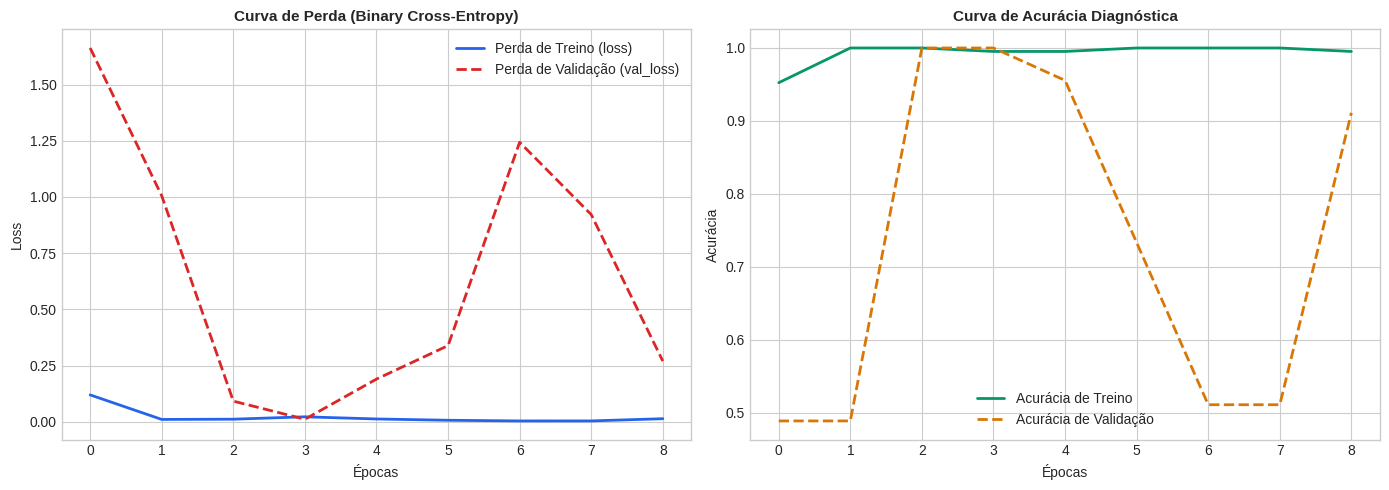

In [7]:
# Gráficos de Evolução do Treinamento: Perda e Acurácia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss
ax1.plot(historico.history['loss'], label='Perda de Treino (loss)', color='#2563eb', linewidth=2)
ax1.plot(historico.history['val_loss'], label='Perda de Validação (val_loss)', color='#dc2626', linewidth=2, linestyle='--')
ax1.set_title("Curva de Perda (Binary Cross-Entropy)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss")
ax1.legend()

# Gráfico de Acurácia
ax2.plot(historico.history['accuracy'], label='Acurácia de Treino', color='#059669', linewidth=2)
ax2.plot(historico.history['val_accuracy'], label='Acurácia de Validação', color='#d97706', linewidth=2, linestyle='--')
ax2.set_title("Curva de Acurácia Diagnóstica", fontsize=11, fontweight='bold')
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Acurácia")
ax2.legend()

plt.tight_layout()
plt.show()

---
## 6. Avaliação Clínica no Conjunto de Teste Independente

Nesta seção, o modelo é desafiado em amostras que não participaram de nenhuma etapa de treinamento ou validação. Calculamos:
1. **Matriz de Confusão:** Inspeção de Verdadeiros Positivos, Falsos Positivos, Verdadeiros Negativos e Falsos Negativos.
2. **Relatório de Classificação:** Métricas de Precision, Recall e F1-Score para cada classe.
3. **Curva ROC e Área sob a Curva (AUC):** Capacidade discriminativa do modelo em diferentes limiares de corte.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
CARDIOIA - DESEMPENHO DO MODELO MLP NO CONJUNTO DE TESTE
Acurácia Global:       100.00%
Sensibilidade (Recall): 100.00% (Taxa de acerto em anomalias)
Precisão:              100.00%
F1-Score:              1.0000

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00        23
 Anormal (1)       1.00      1.00      1.00        22

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



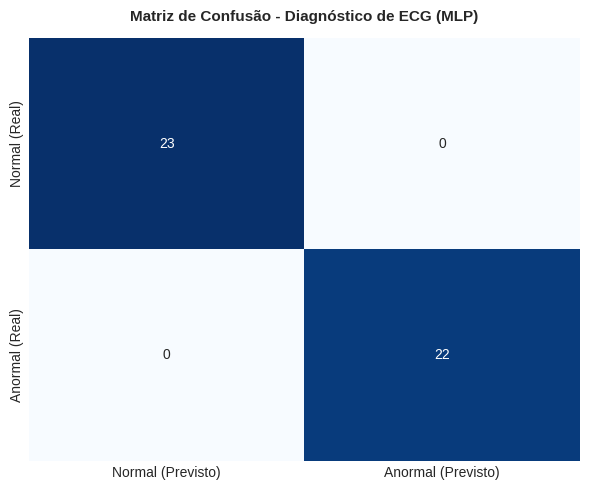

In [8]:
# Predições contínuas e binarizadas no conjunto de teste
y_pred_probs = modelo_mlp.predict(X_test).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)

acc_teste = accuracy_score(y_test, y_pred)
rec_teste = recall_score(y_test, y_pred)
prec_teste = precision_score(y_test, y_pred)
f1_teste = f1_score(y_test, y_pred)

print("=" * 70)
print("CARDIOIA - DESEMPENHO DO MODELO MLP NO CONJUNTO DE TESTE")
print("=" * 70)
print(f"Acurácia Global:       {acc_teste * 100:.2f}%")
print(f"Sensibilidade (Recall): {rec_teste * 100:.2f}% (Taxa de acerto em anomalias)")
print(f"Precisão:              {prec_teste * 100:.2f}%")
print(f"F1-Score:              {f1_teste:.4f}")

print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Anormal (1)']))

# Matriz de Confusão com Seaborn Heatmap
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal (Previsto)', 'Anormal (Previsto)'],
    yticklabels=['Normal (Real)', 'Anormal (Real)'],
    ax=ax,
    cbar=False
)
ax.set_title("Matriz de Confusão - Diagnóstico de ECG (MLP)", fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

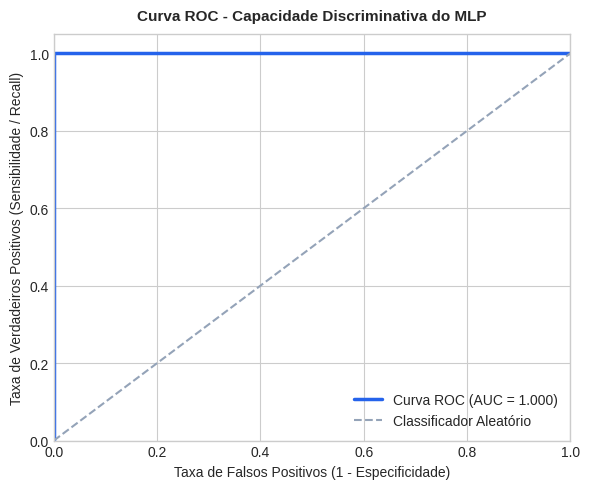

Área sob a Curva ROC (AUC): 1.0000


In [9]:
# Cálculo da Curva ROC e AUC
fpr, tpr, limiares = roc_curve(y_test, y_pred_probs)
valor_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2.5, label=f'Curva ROC (AUC = {valor_auc:.3f})')
ax.plot([0, 1], [0, 1], color='#94a3b8', linestyle='--', linewidth=1.5, label='Classificador Aleatório')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)')
ax.set_title('Curva ROC - Capacidade Discriminativa do MLP', fontsize=11, fontweight='bold', pad=10)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Área sob a Curva ROC (AUC): {valor_auc:.4f}")

---
## 7. Discussão Crítica, Governança e Transição para a Fase 4

### 1. O MLP como Modelo de Linha de Base (Baseline) para Imagens
* O **Multilayer Perceptron (MLP)** requer que a imagem seja achatada num vetor unidimensional de 4096 posições. Ao fazer isso, o modelo **destrói a correlação espacial 2D** entre píxeis vizinhos (relações topo-base e esquerda-direita essenciais para analisar o declive de ondas cardíacas).
* Como consequência, o MLP depende de uma posição fixa do sinal na imagem. Se o traçado do ECG sofrer um leve deslocamento horizontal ou vertical, o MLP precisará de aprender a mesma morfologia em novas coordenadas.

### 2. Vantagens da Migração para Redes Neurais Convolucionais (CNNs) na Fase 4
* Na **Fase 4 (Coração em Imagens)**, a arquitetura recomendada consiste em **CNNs (ex: Conv2D, Pooling e ResNet)**.
* As CNNs possuem **invariância espacial e translacional**: filtros convolucionais deslizam pela imagem detectando bordas, picos e morfologias (ondas P, complexos QRS, supra/infradesnivelamento de ST) independentemente do enquadramento do papel milimetrado.
* Além disso, CNNs permitem o uso de técnicas de explicabilidade visual como **Grad-CAM (Gradient-weighted Class Activation Mapping)**, destacando em mapa de calor exatamente qual segmento do traçado levou o modelo à predição.

### 3. Segurança do Paciente e Assimetria de Custos Clínicos
* Em cardiologia de urgência, a assimetria do erro é drástica:
  * **Falso Negativo (Risco Letal):** Diagnosticar um traçado com Infarto Agudo do Miocárdio (IAM) como 'Normal'. O paciente é liberado inadvertidamente e evolui para choque cardiogênico ou óbito.
  * **Falso Positivo (Custo Operacional):** Classificar um traçado ruidoso como 'Anormal'. O paciente realiza exames laboratoriais complementares (troponina ultrassensível) e novo ECG, preservando a vida.
* Em decorrência dessa assimetria, o ajuste do limiar de decisão (threshold) da sigmoid deve favorecer um **Recall máximo** (Sensibilidade $\ge 98\%$), mesmo com leve perda de especificidade.